In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__12_.zip

Saving archive (12).zip to archive (12).zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with zipfile.ZipFile('archive (12).zip', 'r') as z:
    z.extractall('.')

# Load only 50000 rows to speed up
df = pd.read_csv('creditcard.csv', nrows=50000)

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\n0 = Legitimate, 1 = Fraud")

Shape: (50000, 31)

First 3 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]

Class distribution:
Class
0    49852
1      148
Name: count, dtype: int64

0 = Legitimate, 1 = Fraud

In [ ]:
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Fraud Percentage ===")
fraud_count = df['Class'].sum()
total = len(df)
print(f"Fraud transactions: {fraud_count}")
print(f"Legitimate transactions: {total - fraud_count}")
print(f"Fraud percentage: {fraud_count/total*100:.2f}%")

=== Basic Statistics ===
               Time            V1            V2            V3            V4  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean   28923.779620     -0.242344      0.010316      0.692829      0.185482   
std    13116.563925      1.887731      1.629766      1.508700      1.400009   
min        0.000000    -56.407510    -72.715728    -32.965346     -5.172595   
25%    21893.500000     -0.992599     -0.564348      0.216729     -0.721295   
50%    33471.500000     -0.245008      0.078253      0.795902      0.191131   
75%    38983.000000      1.155544      0.731591      1.430980      1.067868   
max    44299.000000      1.960497     18.183626      4.101716     16.491217   

                 V5            V6            V7            V8            V9  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean      -0.258043      0.105202     -0.120580      0.053704      0.120198   
std        1.412611      1

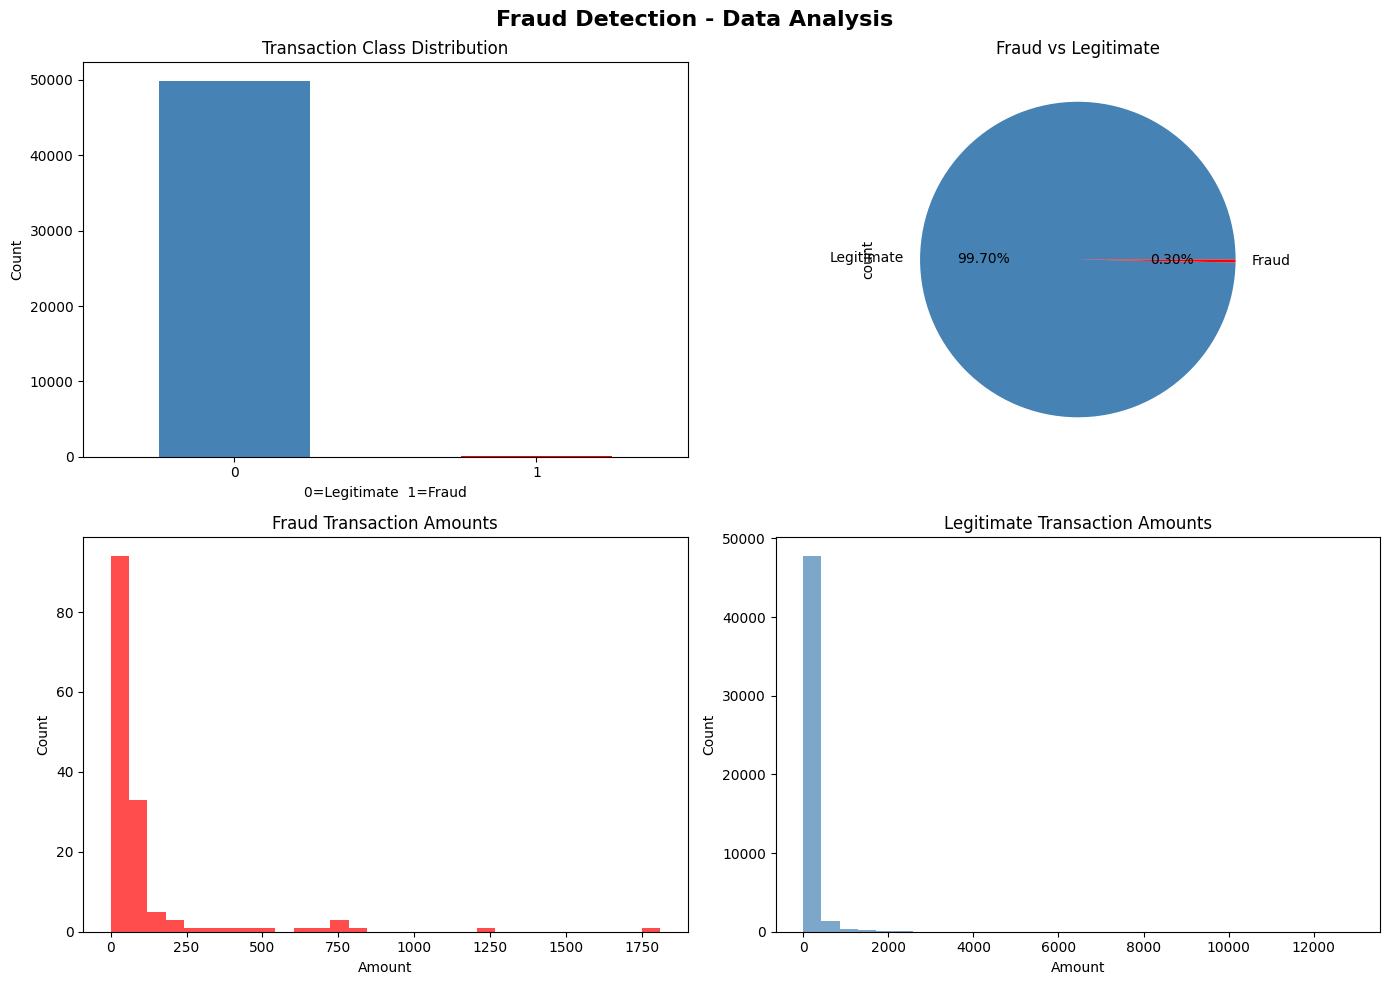

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Class distribution
df['Class'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['steelblue','red'])
axes[0,0].set_title('Transaction Class Distribution')
axes[0,0].set_xlabel('0=Legitimate  1=Fraud')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2 - Class pie chart
df['Class'].value_counts().plot(
    kind='pie', ax=axes[0,1], autopct='%1.2f%%',
    colors=['steelblue','red'],
    labels=['Legitimate','Fraud'])
axes[0,1].set_title('Fraud vs Legitimate')

# Chart 3 - Amount distribution for fraud
fraud_amounts = df[df['Class']==1]['Amount']
axes[1,0].hist(fraud_amounts, bins=30, color='red', alpha=0.7)
axes[1,0].set_title('Fraud Transaction Amounts')
axes[1,0].set_xlabel('Amount')
axes[1,0].set_ylabel('Count')

# Chart 4 - Amount distribution for legitimate
legit_amounts = df[df['Class']==0]['Amount']
axes[1,1].hist(legit_amounts, bins=30, color='steelblue', alpha=0.7)
axes[1,1].set_title('Legitimate Transaction Amounts')
axes[1,1].set_xlabel('Amount')
axes[1,1].set_ylabel('Count')

plt.suptitle('Fraud Detection - Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== ANOMALY DETECTION ===

Fraud transactions - Amount stats:
  Mean:   $100.17
  Max:    $1809.68
  Median: $9.56

Legitimate transactions - Amount stats:
  Mean:   $93.25
  Max:    $12910.93
  Median: $25.00


<Figure size 800x500 with 0 Axes>

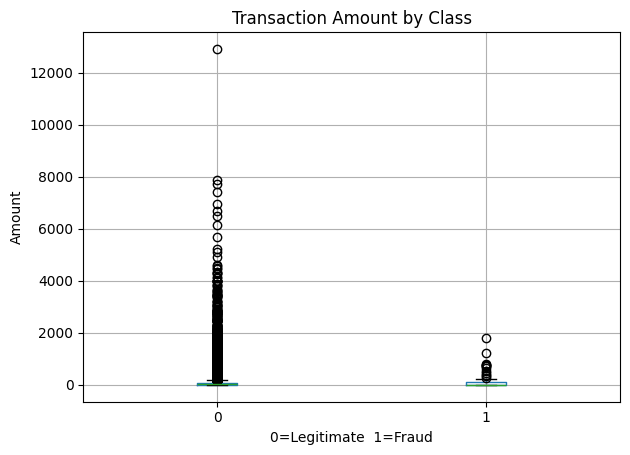

In [ ]:
print("=== ANOMALY DETECTION ===")

# Compare fraud vs legitimate statistics
fraud = df[df['Class']==1]
legit = df[df['Class']==0]

print(f"\nFraud transactions - Amount stats:")
print(f"  Mean:   ${fraud['Amount'].mean():.2f}")
print(f"  Max:    ${fraud['Amount'].max():.2f}")
print(f"  Median: ${fraud['Amount'].median():.2f}")

print(f"\nLegitimate transactions - Amount stats:")
print(f"  Mean:   ${legit['Amount'].mean():.2f}")
print(f"  Max:    ${legit['Amount'].max():.2f}")
print(f"  Median: ${legit['Amount'].median():.2f}")

# Box plot comparison
plt.figure(figsize=(8,5))
df.boxplot(column='Amount', by='Class')
plt.title('Transaction Amount by Class')
plt.suptitle('')
plt.xlabel('0=Legitimate  1=Fraud')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df_model = df.drop(['Time', 'Amount'], axis=1)

# Features and target
X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (50000, 30)
Target distribution:
Class
0    49852
1      148
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

# Undersample majority class
legit_sample = df_model[df_model['Class']==0].sample(
    n=len(df_model[df_model['Class']==1]),
    random_state=42)
fraud_sample = df_model[df_model['Class']==1]

# Combine
balanced_df = pd.concat([legit_sample, fraud_sample])
balanced_df = balanced_df.sample(frac=1, random_state=42)

X_balanced = balanced_df.drop('Class', axis=1)
y_balanced = balanced_df['Class']

print("Balanced dataset shape:", balanced_df.shape)
print("Class distribution after balancing:")
print(y_balanced.value_counts())

Balanced dataset shape: (296, 31)
Class distribution after balancing:
Class
1    148
0    148
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 236
Testing size: 60


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {acc_lr*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate','Fraud']))

=== LOGISTIC REGRESSION ===
Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97        34
       Fraud       0.96      0.96      0.96        26

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("=== DECISION TREE ===")
print(f"Accuracy: {acc_dt*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Legitimate','Fraud']))

=== DECISION TREE ===
Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97        34
       Fraud       0.96      0.96      0.96        26

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



In [ ]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(64, 32),
                   max_iter=500, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
acc_nn = accuracy_score(y_test, y_pred_nn)

print("=== NEURAL NETWORK ===")
print(f"Accuracy: {acc_nn*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn,
      target_names=['Legitimate','Fraud']))

=== NEURAL NETWORK ===
Accuracy: 98.33%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99        34
       Fraud       1.00      0.96      0.98        26

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



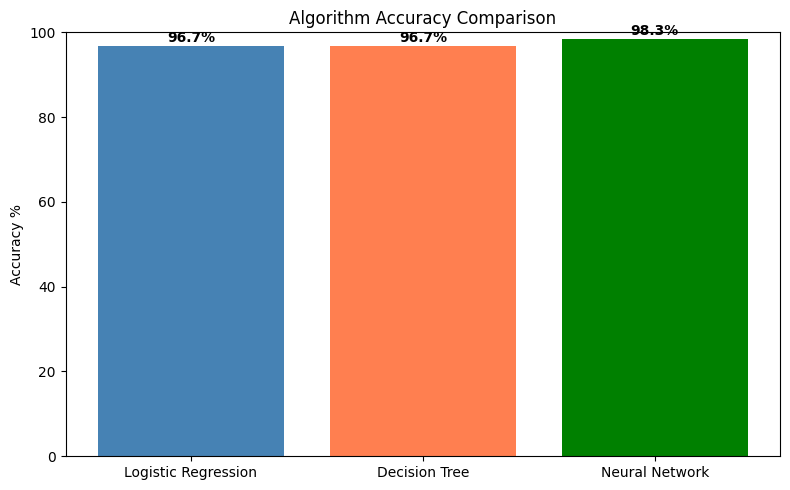


Best Model: Neural Network with 98.33% accuracy


In [ ]:
models = {
    'Logistic Regression': acc_lr * 100,
    'Decision Tree': acc_dt * 100,
    'Neural Network': acc_nn * 100
}

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'coral', 'green']
bars = plt.bar(models.keys(), models.values(), color=colors)
plt.title('Algorithm Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
for bar, val in zip(bars, models.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 1, f'{val:.1f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best = max(models, key=models.get)
print(f"\nBest Model: {best} with {models[best]:.2f}% accuracy")

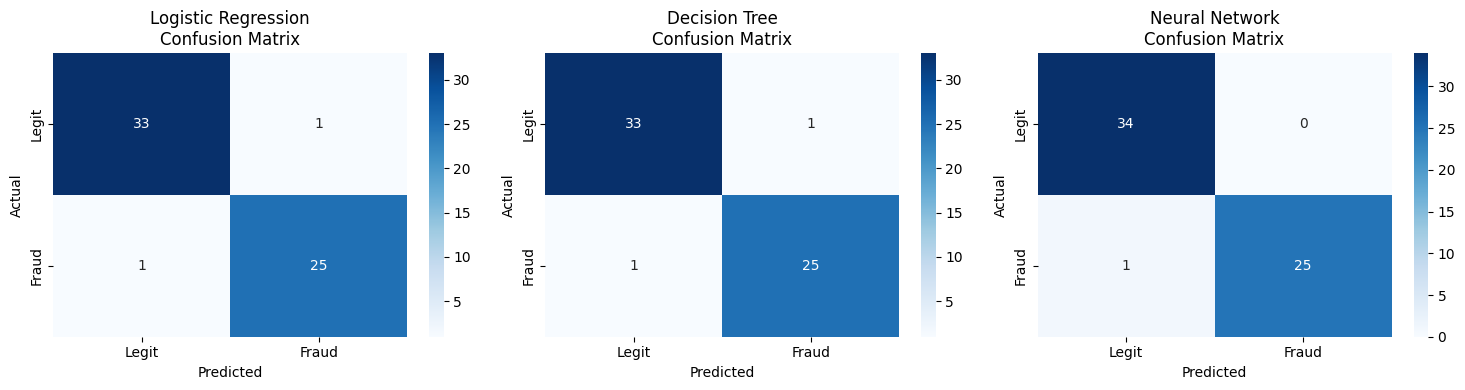

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt, y_pred_nn],
    ['Logistic Regression', 'Decision Tree', 'Neural Network']):

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'], ax=ax)
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
print("=== FRAUD DETECTION PROJECT SUMMARY ===\n")
print(f"Dataset: {len(df):,} transactions analyzed")
print(f"Fraud transactions found: {df['Class'].sum():,}")
print(f"Fraud rate: {df['Class'].sum()/len(df)*100:.2f}%")
print(f"\nModel Accuracies:")
for name, acc in models.items():
    print(f"  {name}: {acc:.2f}%")
print(f"\nBest Model: {best} ({models[best]:.2f}%)")
print("\nSteps Completed:")
print("  ✅ Anomaly Detection")
print("  ✅ Feature Engineering")
print("  ✅ Handling Imbalanced Data")
print("  ✅ Logistic Regression")
print("  ✅ Decision Tree")
print("  ✅ Neural Network")
print("  ✅ Algorithm Comparison")
print("  ✅ Confusion Matrix Analysis")
print("\nFraud Detection system built successfully! 🔐")

=== FRAUD DETECTION PROJECT SUMMARY ===

Dataset: 50,000 transactions analyzed
Fraud transactions found: 148
Fraud rate: 0.30%

Model Accuracies:
  Logistic Regression: 96.67%
  Decision Tree: 96.67%
  Neural Network: 98.33%

Best Model: Neural Network (98.33%)

Steps Completed:
  ✅ Anomaly Detection
  ✅ Feature Engineering
  ✅ Handling Imbalanced Data
  ✅ Logistic Regression
  ✅ Decision Tree
  ✅ Neural Network
  ✅ Algorithm Comparison
  ✅ Confusion Matrix Analysis

Fraud Detection system built successfully! 🔐
